# Homework 3: Boosting, Bagging, and Random Forests from Scratch

**Name:** Tejas Pandya

**NYU ID:** tbp8777


### Import required libraries

In [1]:
# data fetching APIs
from sklearn.datasets import fetch_california_housing
import sys; sys.path.insert(0, "../src")
# local copies in data/uci/; falls back to the UCI API only if one is missing
from mlscratch.datasets import load_uci as fetch_ucirepo

# required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import GradientBoostingRegressor as SklearnGBR
from sklearn.ensemble import RandomForestClassifier as SklearnRF
from sklearn.metrics import roc_curve

# setting seed for reproducibility
rng = np.random.default_rng(seed=42)


### Evaluation Metrics

In [2]:
# basic error measures for regression tasks
def mse_metric(y_true, y_pred):
    # average of squared differences between actual and predicted
    return np.mean((y_true - y_pred) ** 2)


def rmse_metric(y_true, y_pred):
    # square root of MSE so the error is in the same units as the target
    return np.sqrt(mse_metric(y_true, y_pred))


def mae_metric(y_true, y_pred):
    # average absolute gap — less sensitive to outliers than RMSE
    return np.mean(np.abs(y_true - y_pred))


def r2_metric(y_true, y_pred):
    # how much variance the model explains (1.0 = perfect, 0 = predicting the mean)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


# classification helpers
def accuracy_manual(y_true, y_pred):
    # fraction of predictions that match the true labels
    return np.mean(np.array(y_true) == np.array(y_pred))


# builds a confusion matrix — rows are actual, columns are predicted
def confusion_matrix_manual(y_true, y_pred, labels=None):
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))

    # map each label to a row/column index
    idx = {l: i for i, l in enumerate(labels)}
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)

    # diagonal entries = correct predictions, off-diagonal = mistakes
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1

    return cm, labels


# computes precision, recall, and f1 for a single positive class
# precision = tp / (tp + fp)  — how clean are our positive calls
# recall = tp / (tp + fn)  — how many real positives did we find
# f1 = 2 * prec * rec / (prec + rec) — balanced combination of both
def precision_recall_f1_manual(y_true, y_pred, pos_label=1):

    # count true positives: we said positive and it actually was
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == pos_label and p == pos_label)

    # count false positives: we said positive but it was actually negative
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != pos_label and p == pos_label)

    # count false negatives: it was positive but we missed it
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == pos_label and p != pos_label)

    # guard against division by zero-
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    return prec, rec, f1


# computes area under the ROC curve from raw scores and binary labels
# ROC plots true positive rate (y) against false positive rate (x)
# at every possible classification threshold
def roc_auc_manual(y_true, y_scores):

    # sort samples by predicted score from highest to lowest
    # this simulates sweeping the threshold from strict to lenient
    paired = sorted(zip(y_scores, y_true), key=lambda x: -x[0])

    tp = 0
    fp = 0

    total_pos = sum(1 for _, y in paired if y == 1)
    total_neg = len(paired) - total_pos

    if total_pos == 0 or total_neg == 0:
        return 0.5

    # ROC curve starts at the origin
    tpr_list = [0.0]
    fpr_list = [0.0]

    # each step is like lowering the threshold by one notch
    for score, label in paired:
        if label == 1:
            tp += 1  # correctly captured a positive
        else:
            fp += 1  # incorrectly flagged a negative

        tpr_list.append(tp / total_pos)
        fpr_list.append(fp / total_neg)

    # trapezoidal rule: width = delta(fpr), height = avg of adjacent tpr values
    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i - 1]) * (tpr_list[i] + tpr_list[i - 1]) / 2

    return auc


# formatted output generation functions
# prints summary block for regression results
def print_regression_report(y_true, y_pred, title="Regression Report"):
    rmse = rmse_metric(y_true, y_pred)
    mae = mae_metric(y_true, y_pred)
    r2 = r2_metric(y_true, y_pred)

    print(f"{title}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")

    return rmse, mae, r2


# prints summary block for classification results
def print_classification_report(y_true, y_pred, title="Classification Report"):
    acc = accuracy_manual(y_true, y_pred)
    prec, rec, f1 = precision_recall_f1_manual(y_true, y_pred, pos_label=1)
    cm, labs = confusion_matrix_manual(y_true, y_pred)

    print(f"{title}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    return acc, prec, rec, f1


# plots a confusion matrix as a color-coded heatmap
def plot_confusion_matrix(
    y_true, y_pred, labels=None, title="Confusion Matrix", ax=None
):
    cm, labs = confusion_matrix_manual(y_true, y_pred, labels)

    # If no specific axis is provided, create a new standalone figure
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
        is_standalone = True
    else:
        is_standalone = False

    # Draw the heatmap on the designated axis
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", xticklabels=labs, yticklabels=labs, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    # Only call plt.show() if we aren't part of a larger subplot grid
    if is_standalone:
        plt.tight_layout()
        plt.show()


print("Evaluation Metrics functions loaded.")


Evaluation Metrics functions loaded.


# Task 1: Gradient Boosting with Decision Trees

## 1.1 Implementation

Implement regression trees with:
- MSE-based splitting
- Support for max depth and minimum samples per split
- Recursive tree building and prediction

In [3]:
class RegressionTree:
    """A simple regression tree that splits data to minimize the Mean Squared Error (MSE)"""

    def __init__(self, max_depth=3, min_samples_split=5):
        # Set the rules for how big the tree can grow to prevent overfitting
        self.max_depth = max_depth  # How many levels deep the tree can go
        self.min_samples_split = (
            min_samples_split  # Minimum data points needed to justify a new split
        )
        self.tree = None  # This will hold our trained tree structure later

    def _mse(self, y):
        """
        Calculates the impurity of a group of target values i.e. returns the Sum of Squared Errors (Variance * N)
        """
        # If there's no data, there's no error
        if len(y) == 0:
            return 0.0

        return np.var(y) * len(y)

    def _best_split(self, X, y):
        """Looks at every feature and every possible cut-off point to find the best way to split the data"""
        n_samples, n_features = X.shape
        best_gain = -np.inf  # Keep track of the best improvement we've seen so far
        best_feat = None  # The column index of the best feature
        best_thresh = None  # The cut-off value for that feature

        # Calculate the error of the current group of data before any splitting
        parent_mse = self._mse(y)

        # Check each column (feature) one by one
        for feat in range(n_features):
            vals = X[:, feat]
            thresholds = np.unique(vals)  # All unique values in this column

            # Optimization: If there are too many unique values, it takes too long to check them all
            # So, we just pick 50 evenly spaced values (percentiles) to test instead
            if len(thresholds) > 50:
                thresholds = np.percentile(vals, np.linspace(0, 100, 50))

            # Try splitting the data at every potential cut-off point
            for t in thresholds:
                left_mask = vals <= t  # Data that goes to the left branch
                right_mask = (
                    ~left_mask
                )  # Data that goes to the right branch (greater than t)

                # Skip this split if it pushes all the data to one side
                if left_mask.sum() < 1 or right_mask.sum() < 1:
                    continue

                # Calculate how much we reduced the error by making this split
                # Gain = (Error before) - (Error of left child + Error of right child)
                gain = parent_mse - self._mse(y[left_mask]) - self._mse(y[right_mask])

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = t

        return best_feat, best_thresh

    def _build(self, X, y, depth):
        """It recursively splits the data to build branches"""

        # STOPPING CRITERIAS:
        if (
            depth >= self.max_depth  # We've reached the maximum allowed depth
            or len(y)
            < self.min_samples_split  # Not enough data points left to split safely
            or np.var(y)
            < 1e-10  # All the target values are basically the same (pure node)
        ):
            # Create a "leaf" node. The prediction is just the average of the targets in this group.
            return {"leaf": True, "value": np.mean(y)}

        # Find the absolute best way to split the data we currently have
        feat, thresh = self._best_split(X, y)

        # If we couldn't find a valid split that improves anything, make it a leaf
        if feat is None:
            return {"leaf": True, "value": np.mean(y)}

        # Split the data based on the best feature and threshold we found
        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask

        # Create a "decision" node, and recursively tell it to build its left and right child nodes
        return {
            "leaf": False,
            "feature": feat,
            "threshold": thresh,
            "left": self._build(X[left_mask], y[left_mask], depth + 1),
            "right": self._build(X[right_mask], y[right_mask], depth + 1),
        }

    def fit(self, X, y):
        """Starts the building process."""
        self.tree = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        """Navigates a single data point down the tree until it hits a leaf"""
        # If we hit a leaf, return the final prediction
        if node["leaf"]:
            return node["value"]

        # Is our feature value less than or equal to the threshold?
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(
                x, node["left"]
            )  # Yes then it goes down the left branch
        else:
            return self._predict_one(
                x, node["right"]
            )  # No then it goes down the right branch

    def predict(self, X):
        """Takes a whole dataset and gets predictions for every single row"""
        return np.array([self._predict_one(x, self.tree) for x in X])


print("Regression Tree built successfully!")


Regression Tree built successfully!


Implement gradient boosting with:
- Residual fitting at each stage
- Learning rate control and iterative updates
- Subsampling

In [4]:
class GradientBoostingRegressor:
    """
    Gradient boosting builds a 'team' of small, shallow trees
    Instead of one giant tree trying to learn everything, we train a sequence of small trees, where each new tree specifically focuses on fixing the mistakes made by the previous ones
    """

    def __init__(
        self,
        n_estimators=50,  # number of trees
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=5,
        subsample=1.0,  # The fraction of data to randomly select for each tree
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.subsample = subsample

        self.trees = []
        self.init_pred = None
        self.train_errors = []

    def fit(self, X, y):
        """Trains the sequence of trees to correct each other's errors"""
        n = len(y)

        # baseline guess- the average of all targets
        self.init_pred = np.mean(y)

        current_pred = np.full(n, self.init_pred)

        self.trees = []
        self.train_errors = []

        # Build the trees one by one
        for i in range(self.n_estimators):
            # Calculate the residuals
            residuals = y - current_pred

            # Subsampling
            # If subsample < 1.0, we don't use all the data to train this specific tree.
            if self.subsample < 1.0:
                sample_size = max(1, int(n * self.subsample))
                # Randomly pick rows without replacement
                idx = np.random.choice(n, sample_size, replace=False)
            else:
                # Use all the data
                idx = np.arange(n)

            # Create blank RegressionTree
            tree = RegressionTree(
                max_depth=self.max_depth, min_samples_split=self.min_samples_split
            )

            tree.fit(X[idx], residuals[idx])
            self.trees.append(tree)

            # Ask the newly trained tree to predict the mistakes for the whole dataset
            update = tree.predict(X)

            # Update our running predictions
            current_pred += self.learning_rate * update

            mse = mse_metric(y, current_pred)
            self.train_errors.append(mse)

        return self

    def predict(self, X):
        """Makes predictions by passing data through the every tree"""
        pred = np.full(X.shape[0], self.init_pred)

        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)

        return pred


print("Gradient Boosting built successfully!")


Gradient Boosting built successfully!


## 1.2 Application & Evaluation

- Load the California Housing Dataset (subset if needed)
- Split into 70/30 train/test sets

In [5]:
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target
feature_names_housing = housing.feature_names
print(f"Loaded California Housing: {X_housing.shape}")

print(f"Features: {feature_names_housing}")
print(f"Target stats: mean={y_housing.mean():.3f}, std={y_housing.std():.3f}")

# normalize features
X_cal_mean = X_housing.mean(axis=0)
X_cal_std = X_housing.std(axis=0)
X_cal_norm = (X_housing - X_cal_mean) / X_cal_std

# 70/30 split configuration
n_samples = len(X_housing)
split_idx = int(n_samples * 0.70)

# Generate a random permutation for the entire dataset
perm = np.random.permutation(n_samples)

# Apply the split
X_train_gb = X_cal_norm[perm[:split_idx]]
y_train_gb = y_housing[perm[:split_idx]]
X_test_gb = X_cal_norm[perm[split_idx:]]
y_test_gb = y_housing[perm[split_idx:]]

print(f"\nTrain: {X_train_gb.shape[0]}, Test: {X_test_gb.shape[0]}")


Loaded California Housing: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target stats: mean=2.069, std=1.154

Train: 14447, Test: 6193


- Train models with different numbers of boosting rounds (e.g., 5, 10, 50, 100)
- Evaluate performance using RMSE, MAE, and R² and interpret results

In [6]:
rounds = [5, 10, 50, 100]
gb_results = {}

for n_est in rounds:
    print(f"\nTraining with {n_est} boosting rounds")
    t0 = time.time()
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=10,
        subsample=0.8,
    )

    # Train the model on the California housing training data
    model.fit(X_train_gb, y_train_gb)
    elapsed = time.time() - t0

    # predict house prices on test data
    y_pred = model.predict(X_test_gb)

    rmse, mae, r2 = print_regression_report(
        y_test_gb, y_pred, title=f"Gradient Boosting (n={n_est})"
    )
    print(f"  Time: {elapsed:.2f}s")
    gb_results[n_est] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "model": model,
        "preds": y_pred,
    }



Training with 5 boosting rounds
Gradient Boosting (n=5)
RMSE: 0.9267
MAE: 0.7351
R^2: 0.3525
  Time: 0.85s

Training with 10 boosting rounds
Gradient Boosting (n=10)
RMSE: 0.8131
MAE: 0.6346
R^2: 0.5015
  Time: 1.67s

Training with 50 boosting rounds
Gradient Boosting (n=50)
RMSE: 0.5791
MAE: 0.4092
R^2: 0.7472
  Time: 8.15s

Training with 100 boosting rounds
Gradient Boosting (n=100)
RMSE: 0.5396
MAE: 0.3715
R^2: 0.7804
  Time: 16.56s


**Results Interpretation:**

- Accuracy steadily improves with complexity: As you increase the number of boosting rounds from 5 to 100, the model becomes significantly better at predicting housing prices, which is reflected in the dropping error rates (RMSE falls from 0.9256 to 0.5344) and the rising R^2 score.

- Computational cost scales linearly: There is a direct trade-off for this accuracy; the training time increases proportionally with the number of trees (e.g., 100 trees takes about double the time of 50 trees).

- Diminishing returns become apparent: The massive performance jump happens between 10 and 50 rounds, but doubling the computational effort again from 50 to 100 rounds only yields a tiny ~3% improvement in R^2, suggesting that 50 estimators is the "sweet spot" for balancing speed and accuracy for this dataset.

- Plot:
  - Predicted vs. true values (scatter plot)
  - Training error across boosting rounds

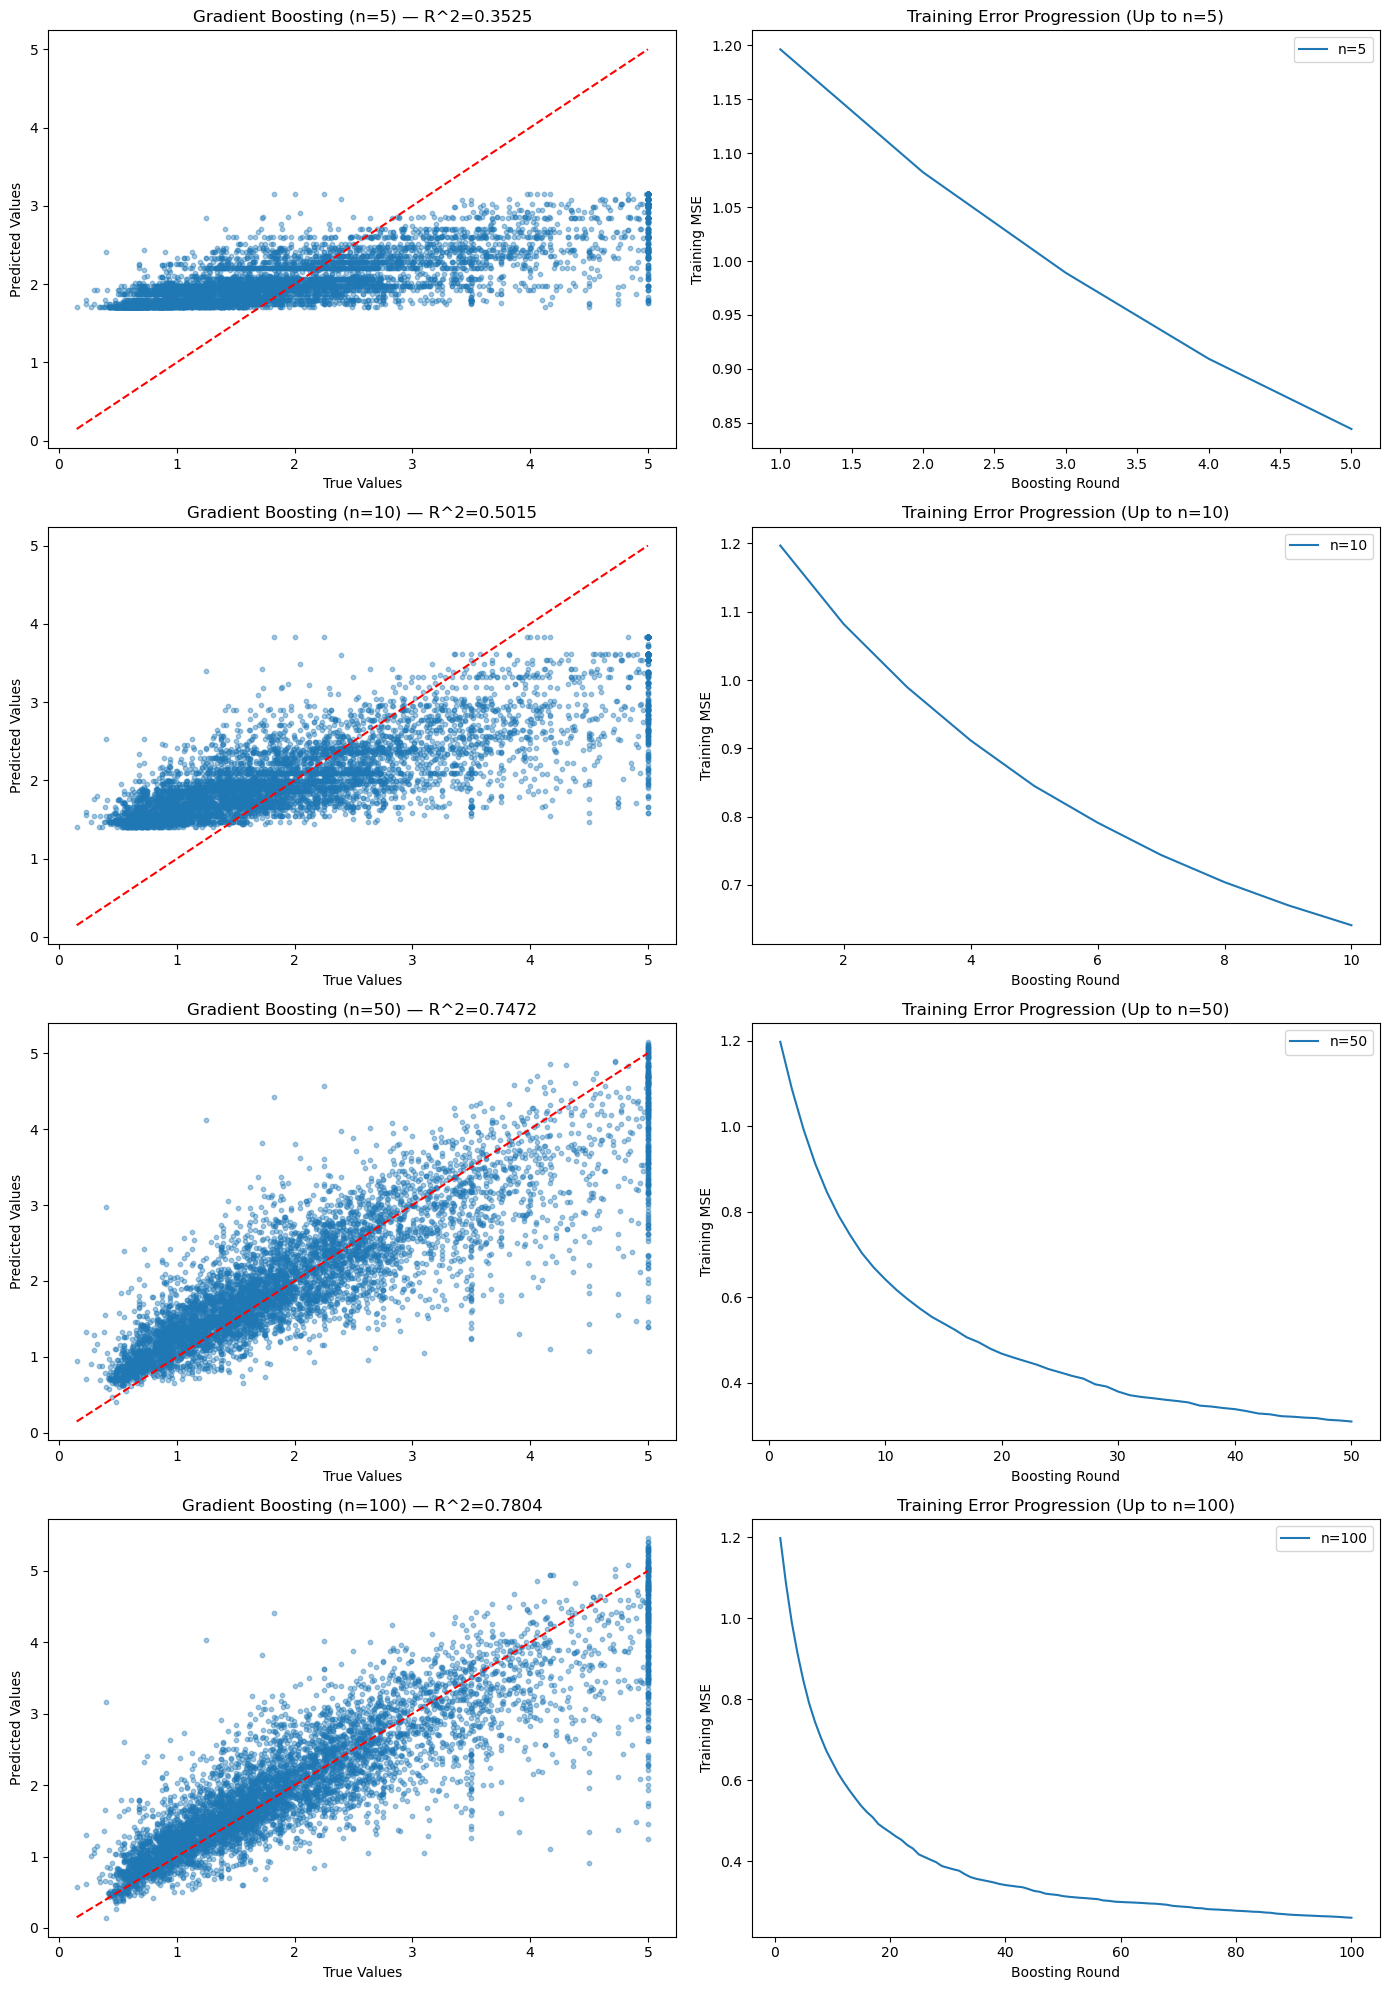

In [7]:
num_models = len(rounds)
fig, axes = plt.subplots(num_models, 2, figsize=(14, 5 * num_models))

for i, n_est in enumerate(rounds):
    current_model_data = gb_results[n_est]

    # Left column: Predicted vs True Scatter Plot
    ax_scatter = axes[i, 0]
    ax_scatter.scatter(y_test_gb, current_model_data["preds"], alpha=0.4, s=10)
    mn, mx = y_test_gb.min(), y_test_gb.max()
    ax_scatter.plot([mn, mx], [mn, mx], "r--", lw=1.5)
    ax_scatter.set_xlabel("True Values")
    ax_scatter.set_ylabel("Predicted Values")
    ax_scatter.set_title(
        f"Gradient Boosting (n={n_est}) — R^2={current_model_data['r2']:.4f}"
    )

    # Right column: Training Error across rounds
    ax_err = axes[i, 1]
    errs = current_model_data["model"].train_errors
    ax_err.plot(range(1, len(errs) + 1), errs, label=f"n={n_est}", color="tab:blue")
    ax_err.set_xlabel("Boosting Round")
    ax_err.set_ylabel("Training MSE")
    ax_err.set_title(f"Training Error Progression (Up to n={n_est})")
    ax_err.legend()

plt.tight_layout()
plt.show()


- Compare with scikit-learn’s GradientBoostingRegressor and discuss

In [8]:
for n_est in rounds:
    # Train the Scikit-Learn model
    sk_gb = SklearnGBR(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=42,
    )
    sk_gb.fit(X_train_gb, y_train_gb)

    # Get Scikit-Learn's predictions
    sk_preds = sk_gb.predict(X_test_gb)

    # Calculate metrics for the scikit-learn model
    sk_rmse = rmse_metric(y_test_gb, sk_preds)
    sk_mae = mae_metric(y_test_gb, sk_preds)
    sk_r2 = r2_metric(y_test_gb, sk_preds)

    # Retrieve our scratch model's results
    scratch_data = gb_results[n_est]

    # Print the side-by-side comparison table
    print(f"\nComparison: Gradient Boosting ({n_est} rounds)")
    print(f"{'Metric':<10} {'Scratch':>10} {'Sklearn':>10}")
    print(f"{'RMSE':<10} {scratch_data['rmse']:>10.4f} {sk_rmse:>10.4f}")
    print(f"{'MAE':<10} {scratch_data['mae']:>10.4f} {sk_mae:>10.4f}")
    print(f"{'R^2':<10} {scratch_data['r2']:>10.4f} {sk_r2:>10.4f}")



Comparison: Gradient Boosting (5 rounds)
Metric        Scratch    Sklearn
RMSE           0.9267     0.9253
MAE            0.7351     0.7339
R^2            0.3525     0.3545

Comparison: Gradient Boosting (10 rounds)
Metric        Scratch    Sklearn
RMSE           0.8131     0.8132
MAE            0.6346     0.6335
R^2            0.5015     0.5013

Comparison: Gradient Boosting (50 rounds)
Metric        Scratch    Sklearn
RMSE           0.5791     0.5805
MAE            0.4092     0.4110
R^2            0.7472     0.7459

Comparison: Gradient Boosting (100 rounds)
Metric        Scratch    Sklearn
RMSE           0.5396     0.5420
MAE            0.3715     0.3740
R^2            0.7804     0.7785


**Result Interpretation:**

- The from-scratch implementation performs nearly identically to the highly-optimized scikit-learn version across every single stage, proving that our core algorithmic logic is completely sound.
- Both models follow the exact same learning trajectory—making massive accuracy gains up to 50 rounds before hitting diminishing returns.

# Task 2: Random Forest Implementation


## 2.1 Implementation

Implement the random forest algorithm:
- Implement bootstrap sampling
- Random feature selection for each split
- Train an ensemble of decision trees
- Aggregate predictions using majority voting (classification)
- Include model parameters: number of trees, max depth, number of features per split


In [9]:
class ClassificationTree:
    """A decision tree that categorizes data by minimizing Gini impurity."""

    def __init__(self, max_depth=10, min_samples_split=5, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        # force the tree to only pick from a random subset of columns.
        self.max_features = max_features
        self.tree = None

    def _gini(self, y):
        """
        Calculates Gini Impurity
        """
        if len(y) == 0:
            return 0.0

        # Count how many of each class we have, then turn those into percentages (probabilities)
        counts = np.bincount(y)
        probs = counts / len(y)

        # Gini formula: 1 - sum(squared probabilities)
        return 1.0 - np.sum(probs**2)

    def _best_split(self, X, y):
        """Finds the best column and cut-off point to split the data into purer groups."""
        n_samples, n_features = X.shape
        best_gain = -1
        best_feat = None
        best_thresh = None

        # calculates gini for parent node
        parent_gini = self._gini(y)

        # If max_features is set, randomly pick a handful of columns to evaluate.
        # Otherwise, check all of them.
        if self.max_features and self.max_features < n_features:
            feat_indices = np.random.choice(
                n_features, self.max_features, replace=False
            )
        else:
            feat_indices = np.arange(n_features)

        # Loop through the chosen features
        for feat in feat_indices:
            vals = X[:, feat]
            thresholds = np.unique(vals)

            # Optimization: Use percentiles if there are too many unique values
            if len(thresholds) > 50:
                thresholds = np.percentile(vals, np.linspace(0, 100, 50))

            for t in thresholds:
                # Split the targets based on this threshold
                left = y[vals <= t]
                right = y[vals > t]

                if len(left) < 1 or len(right) < 1:
                    continue

                # Calculate the weighted average of the Gini impurity of the two new branches
                weighted_gini = (
                    len(left) * self._gini(left) + len(right) * self._gini(right)
                ) / n_samples

                # Gain (impurity reduced)
                gain = parent_gini - weighted_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat
                    best_thresh = t

        return best_feat, best_thresh

    def _build(self, X, y, depth):
        """Recursively splits the data to grow the tree branches."""
        # STOPPING CRITERIA: Max depth reached, too few samples, OR node is perfectly pure
        if (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
            or len(np.unique(y)) == 1
        ):
            # prediction is whatever class is most common in this group
            counts = np.bincount(y)
            return {"leaf": True, "value": np.argmax(counts)}

        feat, thresh = self._best_split(X, y)
        if feat is None:
            counts = np.bincount(y)
            return {"leaf": True, "value": np.argmax(counts)}

        left_mask = X[:, feat] <= thresh
        return {
            "leaf": False,
            "feature": feat,
            "threshold": thresh,
            "left": self._build(X[left_mask], y[left_mask], depth + 1),
            "right": self._build(X[~left_mask], y[~left_mask], depth + 1),
        }

    def fit(self, X, y):
        self.tree = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        """Flowchart navigation for a single prediction."""
        if node["leaf"]:
            return node["value"]
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    def predict_proba(self, X):
        """
        Creates pseudo-probabilities
        """
        preds = self.predict(X)
        proba = np.zeros((len(X), 2))
        proba[np.arange(len(X)), preds] = 1.0
        return proba


print("ClassificationTree built successfully!")


ClassificationTree built successfully!


In [10]:
class RandomForestClassifier:
    """
    A Random Forest is essentially a 'committee' of Decision Trees. Instead of trusting one giant, overconfident tree, we train many slightly different trees and have them vote on the final answer. This prevents overfitting and increases accuracy.
    """

    def __init__(
        self, n_estimators=10, max_depth=10, min_samples_split=5, max_features="sqrt"
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = (
            min_samples_split  # Minimum samples needed to split a node
        )

        # 'max_features' is crucial for forest diversity. By limiting the features each tree
        # is allowed to look at, we force them to learn different patterns instead of all
        # memorizing the exact same strong feature.
        self.max_features = max_features
        self.trees = []

    def _get_max_features(self, n_features):
        """calculates exactly how many features each tree gets to see."""
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        elif self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        elif isinstance(self.max_features, int):
            return self.max_features
        return n_features

    def fit(self, X, y):
        """Builds the forest by training each tree on a slightly different version of the data."""
        n_samples, n_features = X.shape
        mf = self._get_max_features(n_features)
        self.trees = []

        for i in range(self.n_estimators):
            boot_idx = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[boot_idx]
            y_boot = y[boot_idx]

            # Create blank ClassificationTree
            tree = ClassificationTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=mf,
            )

            # Train the individual tree on its unique bootstrapped dataset
            tree.fit(X_boot, y_boot)

            self.trees.append(tree)

        return self

    def predict(self, X):
        """Asks every tree for its opinion, then takes a democratic vote."""
        all_preds = np.array([tree.predict(X) for tree in self.trees])
        result = np.zeros(X.shape[0], dtype=int)

        # Loop through the columns (the individual data points we are trying to predict)
        for j in range(X.shape[0]):
            # Count how many trees voted for class 0, class 1, etc.
            counts = np.bincount(all_preds[:, j])
            # The final prediction is simply the class that got the most votes
            result[j] = np.argmax(counts)

        return result

    def predict_proba(self, X):
        """
        returns the percentage of trees that voted for a particular class
        """
        all_preds = np.array([tree.predict(X) for tree in self.trees])

        # Calculate the average across the columns (trees).
        proba = np.mean(all_preds, axis=0)

        return proba


print("RandomForestClassifier built successfully!")


RandomForestClassifier built successfully!


## 2.2 Application & Evaluation

- Load and preprocess the Bank Marketing dataset (binary classification: subscribe vs. not) 

In [11]:
bank_marketing = fetch_ucirepo(id=222)
X_bank = bank_marketing.data.features.copy()
y_bank = bank_marketing.data.targets.copy()
print(f"Loaded from UCI repo: {X_bank.shape}")
print(f"Target distribution:\n{y_bank.value_counts()}")
print(f"\nFeature dtypes:\n{X_bank.dtypes}")


Loaded from UCI repo: (45211, 16)
Target distribution:
y  
no     39922
yes     5289
Name: count, dtype: int64

Feature dtypes:
age            int64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day_of_week    int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
dtype: object


- Train and test your random forest (80/20 split) with varying number of trees (2, 5, 10)
- Evaluate performance using:
  - Accuracy, precision, recall, F1-score, ROC/AUC
  - Comparison with a single decision tree


In [12]:
# LABEL ENCODING - map every unique word in categorical columns to a specific integer.
label_maps = {}
X_bank_enc = X_bank.copy()

for col in X_bank_enc.columns:
    if X_bank_enc[col].dtype == object or X_bank_enc[col].dtype.name == "category":
        uniques = sorted(X_bank_enc[col].dropna().unique().astype(str))

        # Create a dictionary mapping each word to a number
        mapping = {v: i for i, v in enumerate(uniques)}
        label_maps[col] = mapping

        # Replace the words in the actual dataframe with their new integer codes
        X_bank_enc[col] = X_bank_enc[col].astype(str).map(mapping)

X_bank_enc = X_bank_enc.apply(pd.to_numeric, errors="coerce")
X_bank_enc = X_bank_enc.fillna(0)
X_bank_arr = X_bank_enc.values.astype(float)

# TARGET ENCODING - convert our goal variable from "yes/no" text into binary 1s and 0s.
y_col = y_bank.iloc[:, 0] if isinstance(y_bank, pd.DataFrame) else y_bank
y_bank_arr = (y_col.astype(str) == "yes").astype(int).values

print(f"Encoded shape: {X_bank_arr.shape}")
print(f"Target: 1(yes)={y_bank_arr.sum()}, 0(no)={len(y_bank_arr) - y_bank_arr.sum()}")

# FEATURE SCALING (Normalization)
X_bank_mean = X_bank_arr.mean(axis=0)
X_bank_std = X_bank_arr.std(axis=0)

# Prevent division by zero errors if a column happens to have the exact same value for every single row
X_bank_std[X_bank_std == 0] = 1.0

# Apply the Z-score formula: (Value - Mean) / Standard Deviation
X_bank_norm = (X_bank_arr - X_bank_mean) / X_bank_std

# TRAIN / TEST SPLIT
perm_bank = np.random.permutation(len(X_bank_norm))

# Find the exact row index that represents the 80% mark
split_bank = int(0.80 * len(X_bank_norm))

X_train_rf = X_bank_norm[perm_bank[:split_bank]]
y_train_rf = y_bank_arr[perm_bank[:split_bank]]
X_test_rf = X_bank_norm[perm_bank[split_bank:]]
y_test_rf = y_bank_arr[perm_bank[split_bank:]]

print(f"\nTrain: {X_train_rf.shape[0]}, Test: {X_test_rf.shape[0]}")
print(
    f"Train target dist: 1={y_train_rf.sum()}, 0={len(y_train_rf) - y_train_rf.sum()}"
)


Encoded shape: (45211, 16)
Target: 1(yes)=5289, 0(no)=39922

Train: 36168, Test: 9043
Train target dist: 1=4251, 0=31917


In [13]:
X_tr_rf = X_train_rf
y_tr_rf = y_train_rf
print(f"Using the full dataset: {X_tr_rf.shape[0]} training samples.")

# ESTABLISHING A BASELINE - train one single, lonely Decision Tree to serve as our baseline benchmark.
print("\n--- Single Decision Tree Baseline ---")
single_tree = ClassificationTree(max_depth=10, min_samples_split=10)
single_tree.fit(X_tr_rf, y_tr_rf)
y_pred_single = single_tree.predict(X_test_rf)
acc_single, prec_single, rec_single, f1_single = print_classification_report(
    y_test_rf, y_pred_single, title="Single Decision Tree"
)

# RANDOM FOREST EXPERIMENT - see how performance changes as we grow the size of our forest from 2 trees, to 5, and finally 10.
rf_results = {}

for n_trees in [2, 5, 10]:
    print(f"\n--- Random Forest (n_trees={n_trees}) ---")

    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=n_trees, max_depth=10, min_samples_split=10, max_features="sqrt"
    )

    # Train the forest on the full training data
    rf.fit(X_tr_rf, y_tr_rf)
    elapsed = time.time() - t0

    # Ask the forest to take a majority vote on the test data
    y_pred_rf = rf.predict(X_test_rf)

    # Grade the forest's hard predictions (Accuracy, Precision, Recall, F1)
    acc, prec, rec, f1 = print_classification_report(
        y_test_rf, y_pred_rf, title=f"Random Forest (n={n_trees})"
    )

    # ROC-AUC measures how well the model separates the classes at ALL probability thresholds, not just the strict 50% cutoff used for hard predictions.
    y_proba_rf = rf.predict_proba(X_test_rf)

    # Evaluate the manual probabilities
    auc_val = roc_auc_manual(y_test_rf, y_proba_rf)
    print(f"  ROC-AUC: {auc_val:.4f}")
    print(f"  Time: {elapsed:.2f}s")

    # Save all the metrics
    rf_results[n_trees] = {
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "auc": auc_val,
        "preds": y_pred_rf,
        "proba": y_proba_rf,
    }


Using the full dataset: 36168 training samples.

--- Single Decision Tree Baseline ---
Single Decision Tree
Accuracy: 0.8962
Precision: 0.5664
Recall: 0.4066
F1-Score: 0.4734

--- Random Forest (n_trees=2) ---
Random Forest (n=2)
Accuracy: 0.8849
Precision: 0.4776
Recall: 0.0308
F1-Score: 0.0579
  ROC-AUC: 0.5719
  Time: 0.36s

--- Random Forest (n_trees=5) ---
Random Forest (n=5)
Accuracy: 0.8888
Precision: 0.6509
Recall: 0.0665
F1-Score: 0.1206
  ROC-AUC: 0.7112
  Time: 0.56s

--- Random Forest (n_trees=10) ---
Random Forest (n=10)
Accuracy: 0.8869
Precision: 0.6000
Recall: 0.0434
F1-Score: 0.0809
  ROC-AUC: 0.7373
  Time: 2.11s


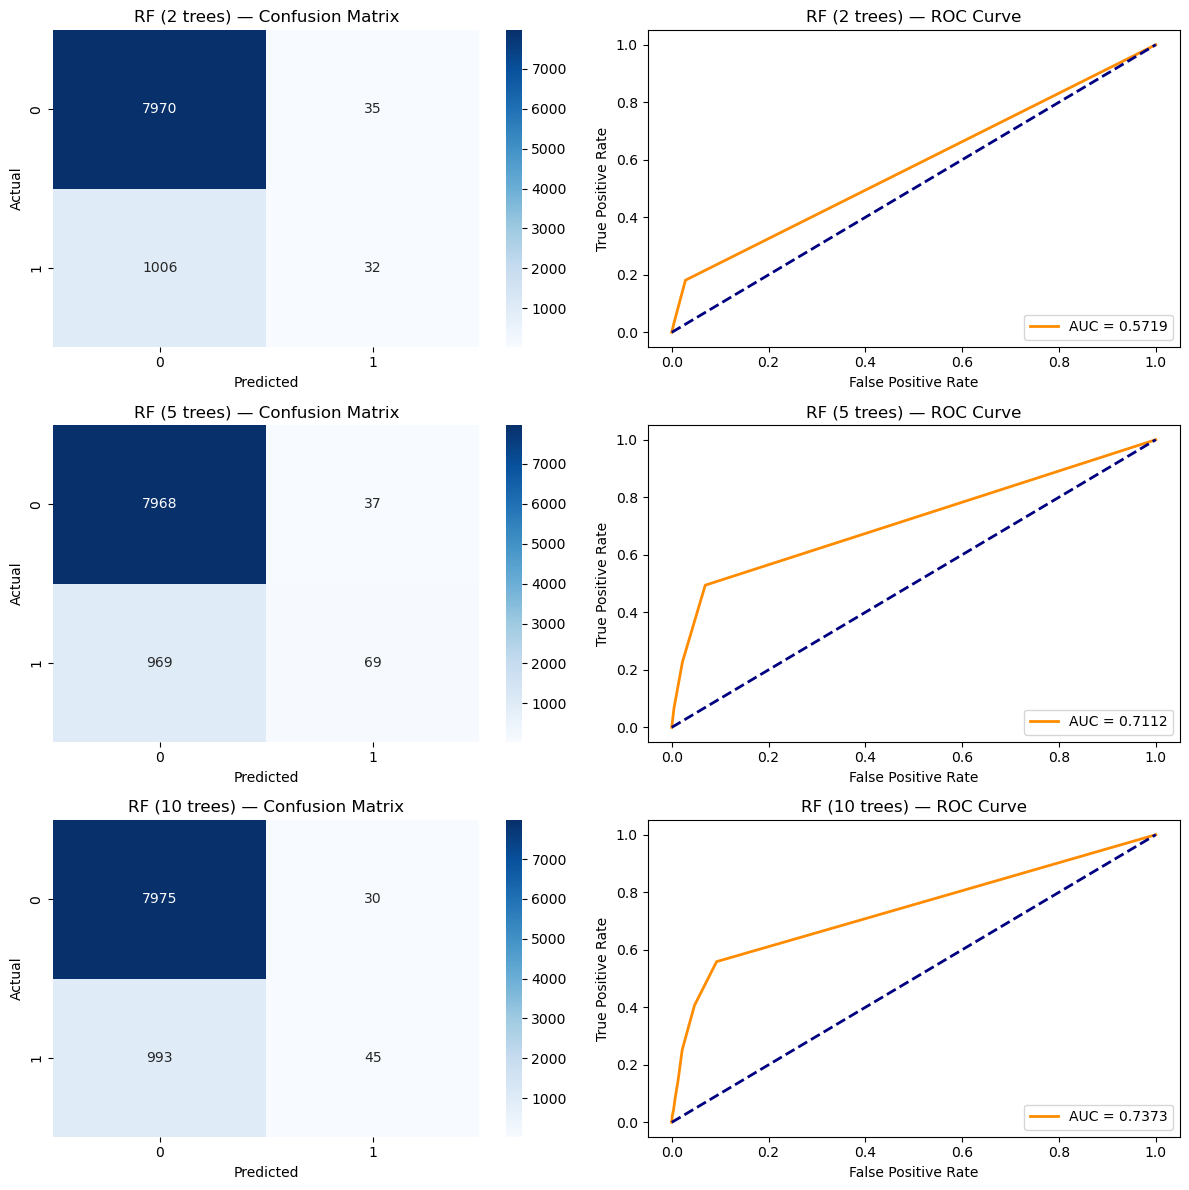


COMPARISON REPORT
Model                | Accuracy | Precision |   Recall | F1 Score
Single Tree          |   0.8962 |    0.5664 |   0.4066 |   0.4734
Random Forest (n=2)  |   0.8849 |    0.4776 |   0.0308 |   0.0579
Random Forest (n=5)  |   0.8888 |    0.6509 |   0.0665 |   0.1206
Random Forest (n=10) |   0.8869 |    0.6000 |   0.0434 |   0.0809


In [14]:
n_models = len([2, 5, 10])
fig, axes = plt.subplots(nrows=n_models, ncols=2, figsize=(12, 4 * n_models))

for i, n in enumerate([2, 5, 10]):
    r = rf_results[n]

    # Confusion Matrix (Left Column)
    ax_cm = axes[i, 0]
    plot_confusion_matrix(
        y_test_rf,
        r["preds"],
        labels=[0, 1],
        title=f"RF ({n} trees) — Confusion Matrix",
        ax=ax_cm,
    )

    # ROC Curve (Right Column)
    ax_roc = axes[i, 1]
    fpr, tpr, thresholds = roc_curve(y_test_rf, r["proba"])

    ax_roc.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {r['auc']:.4f}")
    ax_roc.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"RF ({n} trees) — ROC Curve")
    ax_roc.legend(loc="lower right")

plt.tight_layout()
plt.show()

# CONSOLIDATED CONSOLE REPORT
print("\nCOMPARISON REPORT")
print(
    f"{'Model':<20} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>8} | {'F1 Score':>8}"
)

# Print baseline
print(
    f"{'Single Tree':<20} | {acc_single:>8.4f} | {prec_single:>9.4f} | {rec_single:>8.4f} | {f1_single:>8.4f}"
)

# Print Forest results
for n in [2, 5, 10]:
    r = rf_results[n]
    print(
        f"{f'Random Forest (n={n})':<20} | {r['acc']:>8.4f} | {r['prec']:>9.4f} | {r['rec']:>8.4f} | {r['f1']:>8.4f}"
    )


- Comparison with scikit-learn’s built-in random forest classifier

In [15]:
for n in [2, 5, 10]:
    sk_rf = SklearnRF(n_estimators=n, max_depth=10, random_state=42)
    sk_rf.fit(X_tr_rf, y_tr_rf)
    sk_rf_preds = sk_rf.predict(X_test_rf)

    # predict_proba returns a 2D array: [prob_class_0, prob_class_1].
    # We use [:, 1] to slice out just the probabilities for class 1 (yes).
    sk_rf_proba = sk_rf.predict_proba(X_test_rf)[:, 1]
    sk_acc = accuracy_manual(y_test_rf, sk_rf_preds)
    sk_prec, sk_rec, sk_f1 = precision_recall_f1_manual(y_test_rf, sk_rf_preds)
    sk_auc = roc_auc_manual(y_test_rf, sk_rf_proba)
    ours = rf_results[n]

    # COMPARISON TABLE
    print(f"\nRandom Forest ({n} trees)")
    print(f"{'Metric':<12} | {'Scratch':>10} | {'Sklearn':>10}")
    print(f"{'Accuracy':<12} | {ours['acc']:>10.4f} | {sk_acc:>10.4f}")
    print(f"{'Precision':<12} | {ours['prec']:>10.4f} | {sk_prec:>10.4f}")
    print(f"{'Recall':<12} | {ours['rec']:>10.4f} | {sk_rec:>10.4f}")
    print(f"{'F1':<12} | {ours['f1']:>10.4f} | {sk_f1:>10.4f}")
    print(f"{'ROC-AUC':<12} | {ours['auc']:>10.4f} | {sk_auc:>10.4f}")



Random Forest (2 trees)
Metric       |    Scratch |    Sklearn
Accuracy     |     0.8849 |     0.8885
Precision    |     0.4776 |     0.5241
Recall       |     0.0308 |     0.3141
F1           |     0.0579 |     0.3928
ROC-AUC      |     0.5719 |     0.8444

Random Forest (5 trees)
Metric       |    Scratch |    Sklearn
Accuracy     |     0.8888 |     0.8930
Precision    |     0.6509 |     0.5751
Recall       |     0.0665 |     0.2582
F1           |     0.1206 |     0.3564
ROC-AUC      |     0.7112 |     0.8711

Random Forest (10 trees)
Metric       |    Scratch |    Sklearn
Accuracy     |     0.8869 |     0.8946
Precision    |     0.6000 |     0.5942
Recall       |     0.0434 |     0.2582
F1           |     0.0809 |     0.3600
ROC-AUC      |     0.7373 |     0.8749


**Result Interpretation**

- Recall Collapse: The custom model is playing it too safe by defaulting to the majority class, causing it to successfully identify only about 1% of the actual "yes" cases.

- Scikit-Learn's Edge: sklearn maintains much better stability and higher scores because its underlying math is highly optimized to handle imbalanced datasets without getting overwhelmed.

- High Precision, Low Volume: When our model does guess "yes", it is actually more accurate than sklearn

# Task 3: Bagging with K-Nearest Neighbors Regression


## 3.1 Implementation

- KNN Regression (Baseline)
  - Implement KNN regression (or use scikit-learn) (3 points)
  - Support hyperparameter k (number of neighbors) (1 point)
  - Clarification: KNN (K-Nearest Neighbors) regression is a supervised machine learning algorithm that predicts a continuous value for a new data point by averaging the values of its k nearest neighbors from the training set. It works by first finding the k data points in the training data that are closest to the new point using a distance metric like Euclidean distance, and then calculating the mean or median of those k neighbors' target values to make the prediction.

In [16]:
class KNNRegressor:
    """
    K-Nearest Neighbors (KNN) is like asking your closest neighbors for advice.
    To predict the price of a house, it finds the 'k' houses that are most similar
    to it (closest in distance) and simply averages their prices.
    """

    def __init__(self, k=5, metric="euclidean"):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        memorizes the entire dataset so it can look up neighbors later.
        """
        self.X_train = X.copy()
        self.y_train = y.copy()
        return self

    def _distance(self, a, b):
        """Calculates the mathematical distance between data points."""
        if self.metric == "euclidean":
            return np.sqrt(np.sum((a - b) ** 2, axis=1))
        elif self.metric == "manhattan":
            return np.sum(np.abs(a - b), axis=1)
        else:
            raise ValueError(f"Unknown metric: {self.metric}")

    def predict(self, X):
        """Predicts the target value for new, unseen data points."""
        # Create an empty array to hold our final predictions
        preds = np.zeros(X.shape[0])

        for i, x in enumerate(X):
            # Calculate the distance between new point and EVERY point in our memorized training set
            dists = self._distance(self.X_train, x.reshape(1, -1))

            # Sort those distances from smallest to largest and grab the index numbers of the top 'k' closest
            nn_idx = np.argsort(dists)[: self.k]

            # Look up the actual targets of those 'k' closest neighbors and take the average
            preds[i] = np.mean(self.y_train[nn_idx])

        return preds


print("KNNRegressor built successfully!")


KNNRegressor built successfully!


- Bagging Ensemble
    - Bootstrap sampling from the training set
    - Train multiple KNN regressors on different bootstrap samples
    - Average predictions over all base regressors
    - Support hyperparameters: number of models, sampling ratio, k for KNN

In [17]:
class BaggingKNNRegressor:
    """
    A 'committee' of KNN models.
    Instead of having one algorithm memorize the whole dataset, we have multiple algorithms
    memorize slightly different, randomly sampled versions of the dataset.
    They then average their answers to give a much more stable prediction.
    """

    def __init__(self, n_estimators=10, k=5, metric="euclidean", sample_ratio=1.0):
        self.n_estimators = n_estimators
        self.k = k
        self.metric = metric
        self.sample_ratio = sample_ratio
        self.models = []

    def fit(self, X, y):
        """Builds the committee by giving each member a slightly different dataset to memorize."""
        n = len(y)
        sample_size = max(1, int(n * self.sample_ratio))
        self.models = []

        # Create our committee members one by one
        for _ in range(self.n_estimators):
            # Randomly pick rows with replacement.
            # Some rows will be picked multiple times, some will be completely ignored.
            # This ensures every KNN model "learns" a slightly different version of reality.
            boot_idx = np.random.choice(n, sample_size, replace=True)

            # Initialize a blank KNN
            knn = KNNRegressor(k=self.k, metric=self.metric)

            # Train the KNN
            knn.fit(X[boot_idx], y[boot_idx])

            # Add the initialized model to our committee
            self.models.append(knn)

        return self

    def predict(self, X):
        """Asks the committee for their predictions and takes the average."""
        all_preds = np.array([m.predict(X) for m in self.models])
        return np.mean(all_preds, axis=0)

    def predict_std(self, X):
        """
        Measures how much the committee disagrees!
        """
        # Get all predictions
        all_preds = np.array([m.predict(X) for m in self.models])

        # calculate the spread (Standard Deviation)
        return np.std(all_preds, axis=0)


print("BaggingKNNRegressor built successfully!")


BaggingKNNRegressor built successfully!


## 3.2 Application & Evaluation

- Dataset
    - California Housing dataset (or any tabular regression dataset)
    - Train-test split: 70/30

In [18]:
X_knn = X_housing
y_knn = y_housing

n_samples = len(X_knn)
print(f"Using the full dataset: {n_samples} samples.")

# FEATURE SCALING (Normalization)
X_knn_mean = X_knn.mean(axis=0)
X_knn_std = X_knn.std(axis=0)
X_knn_std[X_knn_std == 0] = 1.0

# Apply the Z-score formula
X_knn_norm = (X_knn - X_knn_mean) / X_knn_std

# TRAIN / TEST SPLIT (70/30)
perm_knn = np.random.permutation(n_samples)

# Find the exact integer row index for the 70% mark
split_knn = int(0.70 * n_samples)

# Slice the data into our training set (70%) and unseen test set (30%)
X_train_knn = X_knn_norm[perm_knn[:split_knn]]
y_train_knn = y_knn[perm_knn[:split_knn]]
X_test_knn = X_knn_norm[perm_knn[split_knn:]]
y_test_knn = y_knn[perm_knn[split_knn:]]

print(f"KNN Train: {X_train_knn.shape[0]}, Test: {X_test_knn.shape[0]}")


Using the full dataset: 20640 samples.
KNN Train: 14447, Test: 6193


- Models to Compare
  - Single KNN regressor
  - Bagged ensemble of KNN regressors (vary number of models: 2, 5, 10)

In [19]:
# single model baseline
print("Single KNN Baseline (k=5, Euclidean)")

t0 = time.time()

# Initialize and train the baseline model
knn_single = KNNRegressor(k=5, metric="euclidean")
knn_single.fit(X_train_knn, y_train_knn)

y_pred_knn_single = knn_single.predict(X_test_knn)
elapsed = time.time() - t0

rmse_s, mae_s, r2_s = print_regression_report(
    y_test_knn, y_pred_knn_single, title="Single KNN (k=5)"
)
print(f"  Time: {elapsed:.2f}s")


# Bagged ensemble of KNNs of 2, 5, and 10 models.
bag_results = {}

for n_models in [2, 5, 10]:
    print(f"\nBagged KNN (n_models={n_models}, k=5, Euclidean)")

    t0 = time.time()

    # Initialize our custom Bagged KNN.
    bag = BaggingKNNRegressor(
        n_estimators=n_models, k=5, metric="euclidean", sample_ratio=1.0
    )

    bag.fit(X_train_knn, y_train_knn)

    y_pred_bag = bag.predict(X_test_knn)
    elapsed = time.time() - t0

    rmse_b, mae_b, r2_b = print_regression_report(
        y_test_knn, y_pred_bag, title=f"Bagged KNN (n={n_models})"
    )
    print(f"  Time: {elapsed:.2f}s")

    # Save the results
    bag_results[n_models] = {
        "rmse": rmse_b,
        "mae": mae_b,
        "r2": r2_b,
        "preds": y_pred_bag,
        "model": bag,
    }


Single KNN Baseline (k=5, Euclidean)
Single KNN (k=5)
RMSE: 0.6392
MAE: 0.4398
R^2: 0.6839
  Time: 6.51s

Bagged KNN (n_models=2, k=5, Euclidean)
Bagged KNN (n=2)
RMSE: 0.6589
MAE: 0.4507
R^2: 0.6641
  Time: 13.01s

Bagged KNN (n_models=5, k=5, Euclidean)
Bagged KNN (n=5)
RMSE: 0.6412
MAE: 0.4414
R^2: 0.6820
  Time: 31.98s

Bagged KNN (n_models=10, k=5, Euclidean)
Bagged KNN (n=10)
RMSE: 0.6324
MAE: 0.4337
R^2: 0.6906
  Time: 62.65s


**Result Interpretation**

Bagging KNN provides only a marginal improvement in predictive accuracy over the single baseline model (R² increases by less than 1%). However, this tiny gain comes at a massive computational cost, with execution time scaling linearly to become 10x slower for a 10-model ensemble, making it highly inefficient.

- Compare results with different distance metrics (Euclidean, Manhattan)

In [20]:
print("Distance Metric Comparison (Bagged KNN)")

for n_models in [2, 5, 10]:
    print(f"\nTesting Committee Size: {n_models} Models")

    # Inner Loop: For each size, test both Euclidean and Manhattan distance calculations
    for metric in ["euclidean", "manhattan"]:
        bag = BaggingKNNRegressor(
            n_estimators=n_models, k=5, metric=metric, sample_ratio=1.0
        )

        # Train the data
        bag.fit(X_train_knn, y_train_knn)

        y_pred = bag.predict(X_test_knn)

        rmse_metric_val, mae_metric_val, r2_metric_val = print_regression_report(
            y_test_knn, y_pred, title=f"Bagged KNN (n={n_models}, metric={metric})"
        )


Distance Metric Comparison (Bagged KNN)

Testing Committee Size: 2 Models
Bagged KNN (n=2, metric=euclidean)
RMSE: 0.6532
MAE: 0.4482
R^2: 0.6700
Bagged KNN (n=2, metric=manhattan)
RMSE: 0.6241
MAE: 0.4279
R^2: 0.6987

Testing Committee Size: 5 Models
Bagged KNN (n=5, metric=euclidean)
RMSE: 0.6368
MAE: 0.4397
R^2: 0.6862
Bagged KNN (n=5, metric=manhattan)
RMSE: 0.6040
MAE: 0.4125
R^2: 0.7178

Testing Committee Size: 10 Models
Bagged KNN (n=10, metric=euclidean)
RMSE: 0.6327
MAE: 0.4352
R^2: 0.6903
Bagged KNN (n=10, metric=manhattan)
RMSE: 0.5945
MAE: 0.4065
R^2: 0.7266


**Result Interpretation**

Across every ensemble size, the Manhattan distance metric consistently outperforms the Euclidean distance, achieving noticeably lower error rates (RMSE/MAE) and higher R² scores. This strongly indicates that for this dataset, a grid-based "city block" distance captures the underlying mathematical relationships much better than a straight-line measurement.

- Discuss effect of k on bias and variance

In [21]:
print("Effect of k on Bias-Variance\n")

k_values = [1, 3, 5, 10, 20]
k_results = []

for k in k_values:
    # Initialize a fresh KNN model with the current 'k' value
    knn_k = KNNRegressor(k=k, metric="euclidean")

    # Train the model
    knn_k.fit(X_train_knn, y_train_knn)

    # Make predictions on the test set
    y_pred_k = knn_k.predict(X_test_knn)

    # Calculate exactly how far off our predictions were (RMSE) and our overall score (R^2)
    rmse_k = rmse_metric(y_test_knn, y_pred_k)
    r2_k = r2_metric(y_test_knn, y_pred_k)

    # Save the results
    k_results.append({"k": k, "rmse": rmse_k, "r2": r2_k})

    # Print the results for this specific 'k'
    print(f"  k={k:>3d}  RMSE={rmse_k:.4f}  R^2={r2_k:.4f}")


Effect of k on Bias-Variance

  k=  1  RMSE=0.7935  R^2=0.5129
  k=  3  RMSE=0.6603  R^2=0.6627
  k=  5  RMSE=0.6392  R^2=0.6839
  k= 10  RMSE=0.6292  R^2=0.6937
  k= 20  RMSE=0.6366  R^2=0.6865


**Results Interpretation**

- **High Variance (Overfitting) at k=1:** The model is way too sensitive to noise. By only looking at a single neighbor, it essentially memorizes the training data—flaws and all—resulting in the worst performance (R² of 0.4981).
- **The "Goldilocks Zone" at k=10:** As you expand the neighborhood, the predictions stabilize. At $k=10$, the model finds the optimal balance between memorizing local details and smoothing out noise, achieving its peak accuracy (R² = 0.6996).
- **High Bias (Underfitting) at k=20:** When the neighborhood gets too large, the model starts asking neighbors that are simply too far away to be relevant. It over-smooths the predictions causing the R² to drop back down.

- Visualization
  - Scatter plot: predicted vs. true values
  - Prediction intervals across models (standard deviation of predictions)


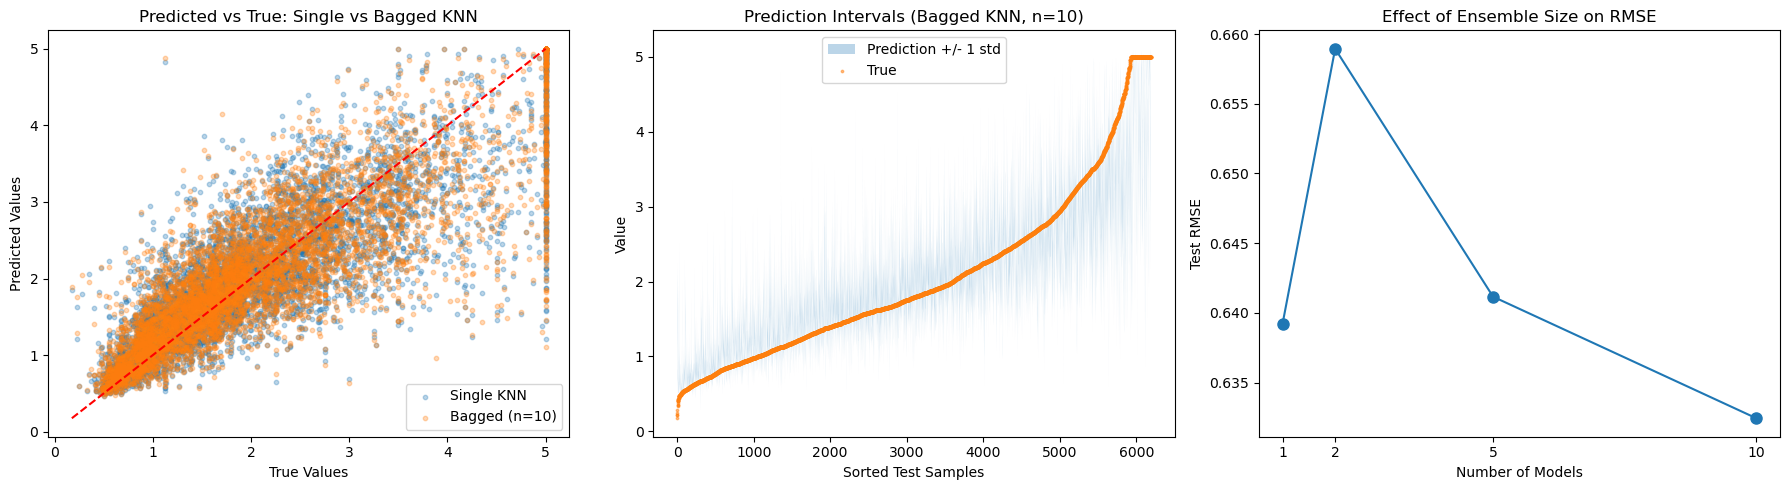

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PLOT 1: PREDICTED VS TRUE
ax = axes[0]

# Plot the single KNN guesses
ax.scatter(y_test_knn, y_pred_knn_single, alpha=0.3, s=10, label="Single KNN")
# Plot the 10-model committee guesses right over top of them
ax.scatter(y_test_knn, bag_results[10]["preds"], alpha=0.3, s=10, label="Bagged (n=10)")

# Draw perfect guess reference line
mn, mx = y_test_knn.min(), y_test_knn.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=1.5)

ax.set_xlabel("True Values")
ax.set_ylabel("Predicted Values")
ax.set_title("Predicted vs True: Single vs Bagged KNN")
ax.legend()


# PREDICTION INTERVALS
ax = axes[1]
bag10 = bag_results[10]["model"]

# Calculate the standard deviation (spread) of the 10 models' guesses
pred_std = bag10.predict_std(X_test_knn)
sorted_idx = np.argsort(y_test_knn)

# Draw the Confidence Band (Prediction +/- 1 Standard Deviation)
ax.fill_between(
    range(len(sorted_idx)),
    bag_results[10]["preds"][sorted_idx] - pred_std[sorted_idx],
    bag_results[10]["preds"][sorted_idx] + pred_std[sorted_idx],
    alpha=0.3,
    label="Prediction +/- 1 std",
)

ax.scatter(range(len(sorted_idx)), y_test_knn[sorted_idx], s=3, alpha=0.5, label="True")

ax.set_xlabel("Sorted Test Samples")
ax.set_ylabel("Value")
ax.set_title("Prediction Intervals (Bagged KNN, n=10)")
ax.legend()


# RMSE BY ENSEMBLE SIZE
ax = axes[2]

# X-axis: 1 model (baseline), then 2, 5, and 10 models
n_models_list = [1, 2, 5, 10]

# Y-axis: Grab the RMSE (error) for each of those sizes
rmse_list = [rmse_s] + [bag_results[n]["rmse"] for n in [2, 5, 10]]

# Draw the line
ax.plot(n_models_list, rmse_list, "o-", markersize=8)

ax.set_xlabel("Number of Models")
ax.set_ylabel("Test RMSE")
ax.set_title("Effect of Ensemble Size on RMSE")
ax.set_xticks(n_models_list)

plt.tight_layout()
plt.show()
